In [1]:
from pathlib import Path

%pip install --quiet --disable-pip-version-check numpy==2.5.3
%pip install --quiet --disable-pip-version-check pandas==3.0.6
%pip install --quiet --disable-pip-version-check matplotlib==3.11.2

%pip install --quiet --disable-pip-version-check scikit-learn==1.9.1
%pip install --quiet --disable-pip-version-check threadpoolctl==3.7.0

import io
import re
import zipfile
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib.ticker import StrMethodFormatter

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

In [2]:
OUTPUT = Path("results/risk_management")
TITLE = "Portfolio risk management"
SOURCE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
START = "2003-01"
END = "2026-08"
COST_BPS = 10
INITIAL_VALUE = 10000
FACTORS = ["Value", "Profitability", "Momentum"]
ASSETS = FACTORS + ["EM market", "Cash"]
DATA = Path("data")
DATA.mkdir(exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

In [3]:
def load_monthly(filename):
    path = DATA / filename
    if not path.exists():
        with urlopen(SOURCE + filename, timeout=30) as response:
            path.write_bytes(response.read())
    with zipfile.ZipFile(path) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        lines = archive.read(member).decode("utf-8-sig").splitlines()
    first = next(i for i, line in enumerate(lines) if re.match(r"^\s*\d{6}\s*,", line))
    last = first
    while last < len(lines) and re.match(r"^\s*\d{6}\s*,", lines[last]):
        last += 1
    frame = pd.read_csv(io.StringIO("\n".join(lines[first - 1:last])), index_col=0)
    frame.columns = frame.columns.str.strip()
    frame.index = pd.to_datetime(frame.index.astype(str).str.strip(), format="%Y%m") + pd.offsets.MonthEnd(0)
    frame.index.name = "Month"
    if not frame.index.is_unique or not frame.index.is_monotonic_increasing:
        raise ValueError("The source dates must be unique and ordered.")
    return frame.apply(pd.to_numeric).replace([-99.99, -999], np.nan) / 100

In [4]:
raw = load_monthly("Emerging_5_Factors_CSV.zip")
momentum = load_monthly("Emerging_MOM_Factor_CSV.zip")
data = raw[["HML", "RMW", "RF"]].copy()
data["WML"] = momentum["WML"]
files = {
    "Value": ("Emerging_Markets_6_Portfolios_ME_BE-ME_CSV.zip", ["SMALL HiBM", "BIG HiBM"]),
    "Profitability": ("Emerging_Markets_6_Portfolios_ME_OP_CSV.zip", ["SMALL HiOP", "BIG HiOP"]),
    "Momentum": ("Emerging_Markets_6_Portfolios_ME_Prior_12_2_CSV.zip", ["SMALL HiPRIOR", "BIG HiPRIOR"]),
}
for factor, (filename, columns) in files.items():
    data[factor] = load_monthly(filename)[columns].mean(axis=1, skipna=False)
data["EM market"] = raw["Mkt-RF"] + raw["RF"]
data["Cash"] = raw["RF"]
data = data.loc[:END]
data = data.loc[data.dropna().index.min():]
if not np.isfinite(data.to_numpy()).all() or (data[ASSETS] <= -1).any().any():
    raise ValueError("The monthly returns contain missing or invalid values.")
if not data.index.to_period("M").equals(pd.period_range(data.index[0], data.index[-1], freq="M")):
    raise ValueError("The monthly history has gaps.")
dates = data.loc[START:END].index
display((data.loc[dates, ASSETS].tail(6) * 100).round(2).rename_axis("Monthly returns (%)"))
display(pd.Series({
    "Source": "Kenneth French emerging-market monthly portfolios",
    "Period": f"{dates[0]:%b %Y} to {dates[-1]:%b %Y}",
    "Factor portfolios": "Average of small and big high-value, high-profitability or winner portfolios",
    "Rebalancing": "Monthly",
    "Trading cost": f"{COST_BPS} basis points on equity purchases and sales",
    "Cash return": "U.S. one-month T-bill proxy from the source",
    "Data limits": "Current historical series; revisions and trading within the source portfolios are not reconstructed",
}, name="Setup").to_frame())

,Value,Profitability,Momentum,EM market,Cash
Monthly returns (%),,,,,
2026-03-31,-10.94,-10.88,-13.28,-12.07,0.29
2026-04-30,9.07,13.18,19.10,13.92,0.29
2026-05-31,1.88,4.78,7.78,7.75,0.31
2026-06-30,-2.26,-1.01,-3.47,-1.69,0.29
2026-07-31,0.88,-3.58,-13.03,-3.89,0.33
2026-08-31,5.46,5.19,10.69,4.66,0.29


,Setup
Source,Kenneth French emerging-market monthly portfolios
Period,Jan 2003 to Aug 2026
Factor portfolios,"Average of small and big high-value, high-prof..."
Rebalancing,Monthly
Trading cost,10 basis points on equity purchases and sales
Cash return,U.S. one-month T-bill proxy from the source
Data limits,Current historical series; revisions and tradi...


In [5]:
def backtest(targets, cost_bps=COST_BPS):
    rows = []
    previous = np.array([0.0, 0.0, 0.0, 0.0, 1.0])
    for date, row in targets.iterrows():
        target = row[ASSETS].to_numpy(dtype=float)
        if not np.isfinite(target).all() or (target < 0).any() or not np.isclose(target.sum(), 1):
            raise ValueError("Portfolio weights must be positive and add up to one.")
        returns = data.loc[date, ASSETS].to_numpy()
        traded = np.abs(target[:-1] - previous[:-1]).sum()
        gross = float(target @ returns)
        cost = float(traded * cost_bps / 10000)
        rows.append({"Month": date, "Gross return": gross, "Net return": (1 - cost) * (1 + gross) - 1,
                     "Traded value": traded, "Cash weight": target[-1]})
        previous = target * (1 + returns) / (1 + gross)
    return pd.DataFrame(rows).set_index("Month")

In [6]:
def summarize(results):
    rows = []
    for name, sample in results.items():
        returns = sample["Net return"]
        wealth = (1 + returns).cumprod()
        peaks = np.maximum.accumulate(np.r_[1.0, wealth.to_numpy()])[1:]
        excess = returns - data.loc[returns.index, "RF"]
        rows.append({
            "Strategy": name,
            "Gross annual return %": ((1 + sample["Gross return"]).prod() ** (12 / len(sample)) - 1) * 100,
            "Net annual return %": (wealth.iloc[-1] ** (12 / len(sample)) - 1) * 100,
            "Volatility %": returns.std(ddof=1) * np.sqrt(12) * 100,
            "Sharpe ratio": excess.mean() / excess.std(ddof=1) * np.sqrt(12),
            "Max drawdown %": (wealth.to_numpy() / peaks - 1).min() * 100,
            "Annual traded value %": sample["Traded value"].mean() * 12 * 100,
            "Average cash %": sample["Cash weight"].mean() * 100,
        })
    return pd.DataFrame(rows).set_index("Strategy")

In [7]:
equal = pd.DataFrame([np.r_[np.full(3, 1 / 3), 0, 0]] * len(dates), index=dates, columns=ASSETS)
market = equal * 0
market["EM market"] = 1
strategies = {"Equal weights": equal, "EM market": market}

In [8]:
TRAIN_MONTHS = 120
SIGNAL_LAG = 2
SEED = 42
features = pd.DataFrame(index=data.index)
features["Market volatility"] = data["EM market"].rolling(6).std() * np.sqrt(12)
features["Market return"] = (1 + data["EM market"]).rolling(6).apply(np.prod, raw=True) - 1
pairs = [("HML", "RMW"), ("HML", "WML"), ("RMW", "WML")]
features["Factor correlation"] = pd.concat([data[a].rolling(12).corr(data[b]) for a, b in pairs], axis=1).mean(axis=1, skipna=False)
future_returns = data[FACTORS].shift(-SIGNAL_LAG)
display(pd.Series({"Training window": f"{TRAIN_MONTHS} months", "Signal lag": f"{SIGNAL_LAG} months before the return month",
                   "Allocation limits": "25% to 50% in each factor before any cash rule",
                   "Publication timing": "A fixed delay is assumed; historical release dates are unavailable"}, name="ML setup").to_frame())

,ML setup
Training window,120 months
Signal lag,2 months before the return month
Allocation limits,25% to 50% in each factor before any cash rule
Publication timing,A fixed delay is assumed; historical release d...


In [9]:
def tilt(scores):
    if np.ptp(scores) < 1e-12:
        return np.full(3, 1 / 3)
    weights = np.full(3, 0.25)
    weights[int(np.argmax(scores))] = 0.5
    return weights

In [10]:
ml_rows, mean_rows, signal_rows = [], [], []
with threadpool_limits(limits=1):
    for date in dates:
        position = data.index.get_loc(date)
        signal_position = position - SIGNAL_LAG
        training_end = signal_position - SIGNAL_LAG
        if training_end < 0:
            raise ValueError("Move START later to provide enough training history.")
        training = features.iloc[:training_end + 1].dropna().tail(TRAIN_MONTHS)
        current = features.iloc[[signal_position]]
        if len(training) != TRAIN_MONTHS or current.isna().any().any():
            raise ValueError("Move START later to provide enough training history.")
        outcomes = future_returns.loc[training.index].to_numpy()
        relative = outcomes - outcomes.mean(axis=1, keepdims=True)
        overall = relative.mean(axis=0)
        scaler = StandardScaler().fit(training)
        model = GaussianMixture(n_components=2, n_init=5, max_iter=500, reg_covar=0.001, random_state=SEED, init_params="k-means++")
        model.fit(scaler.transform(training))
        if not model.converged_:
            raise ValueError("The regime model did not converge.")
        responsibilities = model.predict_proba(scaler.transform(training))
        probabilities = model.predict_proba(scaler.transform(current))[0]
        targets = []
        for state in range(2):
            support = responsibilities[:, state].sum()
            scores = (responsibilities[:, state] @ relative + 24 * overall) / (support + 24)
            targets.append(tilt(scores) if support >= 12 else np.full(3, 1 / 3))
        weights = probabilities @ np.asarray(targets)
        high_state = np.argmax(scaler.inverse_transform(model.means_)[:, 0])
        ml_rows.append(np.r_[weights, 0, 0])
        mean_rows.append(np.r_[tilt(overall), 0, 0])
        signal_rows.append({"Month": date, "Signal month": data.index[signal_position], "Training feature end": training.index[-1],
                            "Training outcome end": data.index[training_end + SIGNAL_LAG], "High volatility probability": probabilities[high_state]})

ml_weights = pd.DataFrame(ml_rows, index=dates, columns=ASSETS)
mean_weights = pd.DataFrame(mean_rows, index=dates, columns=ASSETS)
signals = pd.DataFrame(signal_rows).set_index("Month")
strategies = {"Equal weights": equal, "Historical mean tilt": mean_weights, "ML allocation": ml_weights, "EM market": market}
display((ml_weights[FACTORS].tail(6) * 100).round(2))

,Value,Profitability,Momentum
Month,,,
2026-03-31,25.0,25.0,50.0
2026-04-30,25.0,25.0,50.0
2026-05-31,25.0,25.0,50.0
2026-06-30,25.0,25.0,50.0
2026-07-31,25.0,25.0,50.0
2026-08-31,25.0,25.0,50.0


In [11]:
RISK_THRESHOLD = 0.60
RISK_CASH = 0.50
FIXED_CASH = 0.25
risk_cash = pd.Series(np.where(signals["High volatility probability"] >= RISK_THRESHOLD, RISK_CASH, 0), index=dates)
adaptive = ml_weights.mul(1 - risk_cash, axis=0)
adaptive["Cash"] = risk_cash
fixed = ml_weights * (1 - FIXED_CASH)
fixed["Cash"] = FIXED_CASH
strategies = {"Equal weights": equal, "ML allocation": ml_weights, "ML + cash rule": adaptive, "ML + fixed cash": fixed}
display(pd.Series({"High-volatility cutoff": RISK_THRESHOLD, "Cash when triggered": f"{RISK_CASH:.0%}",
                   "Cash otherwise": "0%", "Fixed-cash comparison": f"{FIXED_CASH:.0%}"}, name="Risk rule").to_frame())

,Risk rule
High-volatility cutoff,0.6
Cash when triggered,50%
Cash otherwise,0%
Fixed-cash comparison,25%


In [12]:
results = {name: backtest(targets) for name, targets in strategies.items()}
performance = summarize(results)
display(performance.round(3))

,Gross annual return %,Net annual return %,Volatility %,Sharpe ratio,Max drawdown %,Annual traded value %,Average cash %
Strategy,,,,,,,
Equal weights,14.355,14.340,19.292,0.711,-61.838,12.538,0.000
ML allocation,14.836,14.761,19.498,0.725,-62.154,64.922,0.000
ML + cash rule,11.142,10.991,17.138,0.603,-56.344,135.656,13.028
ML + fixed cash,11.820,11.761,14.630,0.724,-50.478,53.255,25.000


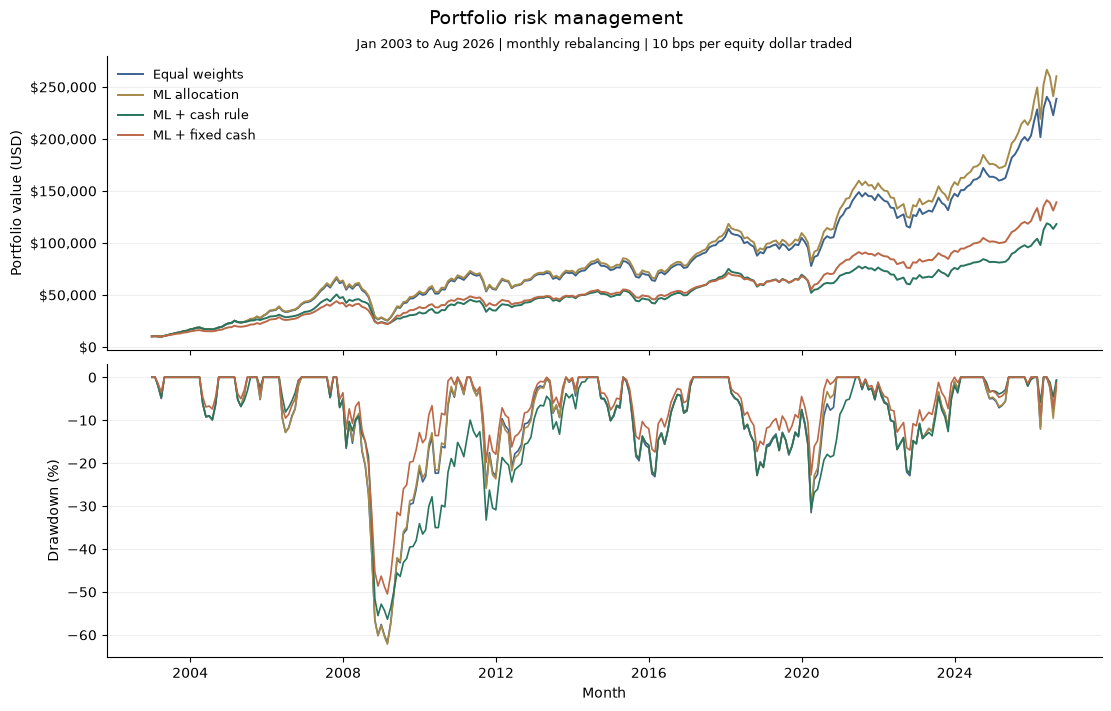

In [13]:
palette = ["#3d638d", "#a58a49", "#28745e", "#bb6847", "#80629e"]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")
for (name, result), color in zip(results.items(), palette):
    wealth = (1 + result["Net return"]).cumprod()
    initial_date = wealth.index[0] - pd.offsets.MonthEnd(1)
    wealth = pd.concat([pd.Series([1.0], index=[initial_date]), wealth])
    axes[0].plot(wealth.index, wealth * INITIAL_VALUE, label=name, color=color, linewidth=1.4)
    axes[1].plot(wealth.index, (wealth / wealth.cummax() - 1) * 100, color=color, linewidth=1.2)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[0].legend(frameon=False, loc="upper left", fontsize=9)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Month")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
fig.suptitle(TITLE, fontsize=14)
axes[0].set_title(f"{dates[0]:%b %Y} to {dates[-1]:%b %Y} | monthly rebalancing | {COST_BPS} bps per equity dollar traded", fontsize=9)
fig.savefig(OUTPUT / "performance.png", dpi=150, bbox_inches="tight")
plt.show()

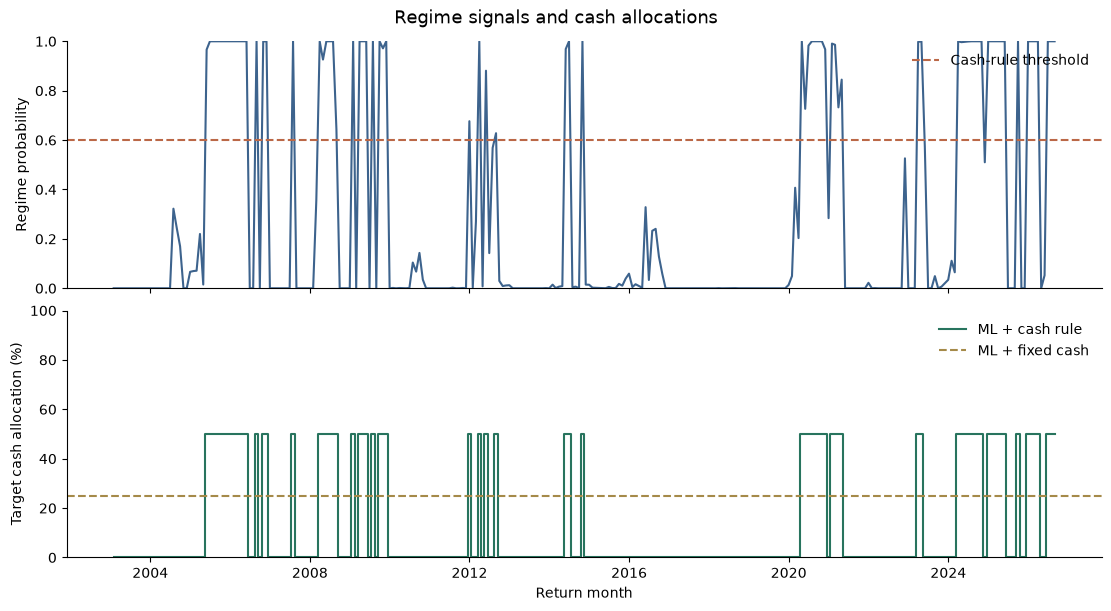

,Risk trade-off
Months with cash,74.000
Total months,284.000
Average cash %,13.028
Average lag in positive ML months (percentage points),0.764


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
axes[0].plot(signals.index, signals["High volatility probability"], color="#3d638d")
axes[0].axhline(RISK_THRESHOLD, color="#bb6847", linestyle="--", label="Cash-rule threshold")
axes[0].set_ylabel("Regime probability")
axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False)
axes[1].step(dates, adaptive["Cash"] * 100, where="mid", color="#28745e", label="ML + cash rule")
axes[1].axhline(FIXED_CASH * 100, color="#a58a49", linestyle="--", label="ML + fixed cash")
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Target cash allocation (%)")
axes[1].set_xlabel("Return month")
axes[1].legend(frameon=False)
fig.suptitle("Regime signals and cash allocations", fontsize=13)
fig.savefig(OUTPUT / "cash_allocations.png", dpi=150, bbox_inches="tight")
plt.show()

positive_months = results["ML allocation"]["Net return"] > 0
upside_gap = (results["ML allocation"].loc[positive_months, "Net return"] - results["ML + cash rule"].loc[positive_months, "Net return"]).mean() * 100
display(pd.Series({"Months with cash": int(risk_cash.gt(0).sum()), "Total months": len(dates),
                   "Average cash %": risk_cash.mean() * 100,
                   "Average lag in positive ML months (percentage points)": upside_gap}, name="Risk trade-off").round(3).to_frame())

In [15]:
cost_rows = []
for cost in [0, 10, 25]:
    summary = summarize({name: backtest(targets, cost) for name, targets in strategies.items()})
    summary.insert(0, "Cost bps", cost)
    cost_rows.append(summary.reset_index())
cost_comparison = pd.concat(cost_rows).set_index(["Cost bps", "Strategy"])
display(cost_comparison[["Net annual return %", "Sharpe ratio", "Max drawdown %"]].round(3))
cost_comparison.to_csv(OUTPUT / "cost_comparison.csv")

Net annual return %  Sharpe ratio  Max drawdown %
Cost bps Strategy                                                          
0        Equal weights                 14.355         0.712         -61.834
         ML allocation                 14.836         0.728         -62.072
         ML + cash rule                11.142         0.611         -56.210
         ML + fixed cash               11.820         0.728         -50.391
10       Equal weights                 14.340         0.711         -61.838
         ML allocation                 14.761         0.725         -62.154
         ML + cash rule                10.991         0.603         -56.344
         ML + fixed cash               11.761         0.724         -50.478
25       Equal weights                 14.319         0.710         -61.844
         ML allocation                 14.650         0.719         -62.276
         ML + cash rule                10.766         0.591         -56.545
         ML + fixed cash               11.672         0.719         -50.608

In [16]:
data.to_csv(OUTPUT / "monthly_inputs.csv", date_format="%Y-%m-%d")
performance.to_csv(OUTPUT / "performance.csv")
pd.concat(results, names=["Strategy", "Month"]).to_csv(OUTPUT / "portfolio_returns.csv", date_format="%Y-%m-%d")
pd.concat(strategies, names=["Strategy", "Month"]).to_csv(OUTPUT / "allocations.csv", date_format="%Y-%m-%d")

In [17]:
signals.to_csv(OUTPUT / "signals.csv", date_format="%Y-%m-%d")

The cash rule changed the ML portfolio's annual return from 14.76% to 10.99% after the assumed costs. Its largest drawdown was 56.34%, compared with 62.15% without the rule. Holding 25% cash throughout returned 11.76% a year with a 50.48% drawdown. Our changing cash allocation averaged 13.0%. In months when the fully invested ML portfolio gained, the cash-rule portfolio lagged by 0.76 percentage points on average. Fixed cash gave a higher return and a smaller worst loss in this sample, so the timing rule did not earn its place here. We would need to check other periods before deciding whether to use it.